In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df = pd.read_csv(
    "data/Sample - Superstore.csv",
    encoding="latin1"
)

df["Order Date"] = pd.to_datetime(df["Order Date"])

In [3]:
#Descriptive Statistics
df[["Sales","Profit","Quantity","Discount"]].describe()

,Sales,Profit,Quantity,Discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,3.789574,0.156203
std,623.245101,234.260108,2.225110,0.206452
min,0.444000,-6599.978000,1.000000,0.000000
25%,17.280000,1.728750,2.000000,0.000000
50%,54.490000,8.666500,3.000000,0.200000
75%,209.940000,29.364000,5.000000,0.200000
max,22638.480000,8399.976000,14.000000,0.800000


In [4]:
#Mean,Median,Mode,Std,Skewness
print("Mean:\n")
print(df[["Sales","Profit"]].mean())

print("\nMedian:\n")
print(df[["Sales","Profit"]].median())

print("\nMode:\n")
print(df[["Sales","Profit"]].mode())

print("\nStandard Deviation:\n")
print(df[["Sales","Profit"]].std())

print("\nSkewness:\n")
print(df[["Sales","Profit"]].skew())

Mean:

Sales     229.858001
Profit     28.656896
dtype: float64

Median:

Sales     54.4900
Profit     8.6665
dtype: float64

Mode:

   Sales  Profit
0  12.96     0.0

Standard Deviation:

Sales     623.245101
Profit    234.260108
dtype: float64

Skewness:

Sales     12.972752
Profit     7.561432
dtype: float64


In [5]:
#T-Test
tech_profit = df[
    df["Category"]=="Technology"
]["Profit"]

furniture_profit = df[
    df["Category"]=="Furniture"
]["Profit"]

t_stat,p_value = stats.ttest_ind(
    tech_profit,
    furniture_profit
)

print("T-statistic:",t_stat)
print("P-value:",p_value)

T-statistic: 7.1232394903693965
P-value: 1.2460761885846871e-12


In [6]:
if p_value < 0.05:
    print("Significant difference exists")
else:
    print("No significant difference")

Significant difference exists


In [7]:
#Chi-Square Test
contingency = pd.crosstab(
    df["Region"],
    df["Category"]
)

chi2,p,dof,expected = stats.chi2_contingency(
    contingency
)

print("Chi-square:",chi2)
print("P-value:",p)

Chi-square: 3.661930938326572
P-value: 0.7223155543986877


In [8]:
#Confidence Interval
sales = df["Sales"]

mean = sales.mean()

ci = stats.t.interval(
    0.95,
    len(sales)-1,
    loc=mean,
    scale=stats.sem(sales)
)

print("95% Confidence Interval:")
print(ci)

95% Confidence Interval:
(np.float64(217.63747489897534), np.float64(242.0785267620212))


In [9]:
#Time Series Analysis
monthly_sales = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Sales"].sum()

monthly_sales.index = monthly_sales.index.to_timestamp()

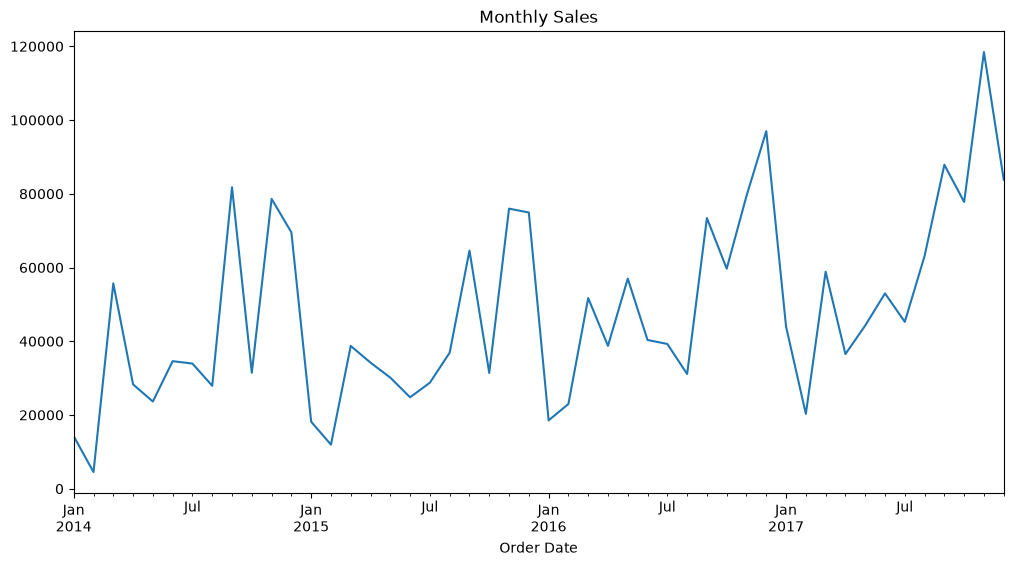

In [10]:
plt.figure(figsize=(12,6))

monthly_sales.plot()

plt.title("Monthly Sales")

plt.savefig(
    "images/monthly_sales.png"
)

plt.show()

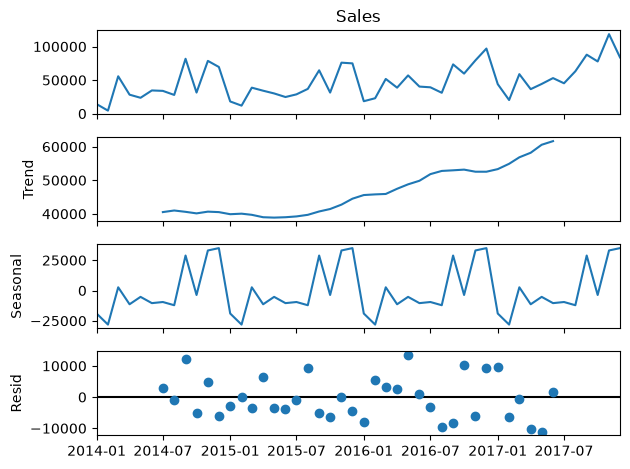

In [11]:
#Decomposition
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

decomposition.plot()

plt.savefig(
    "images/time_series_decomposition.png"
)

plt.show()

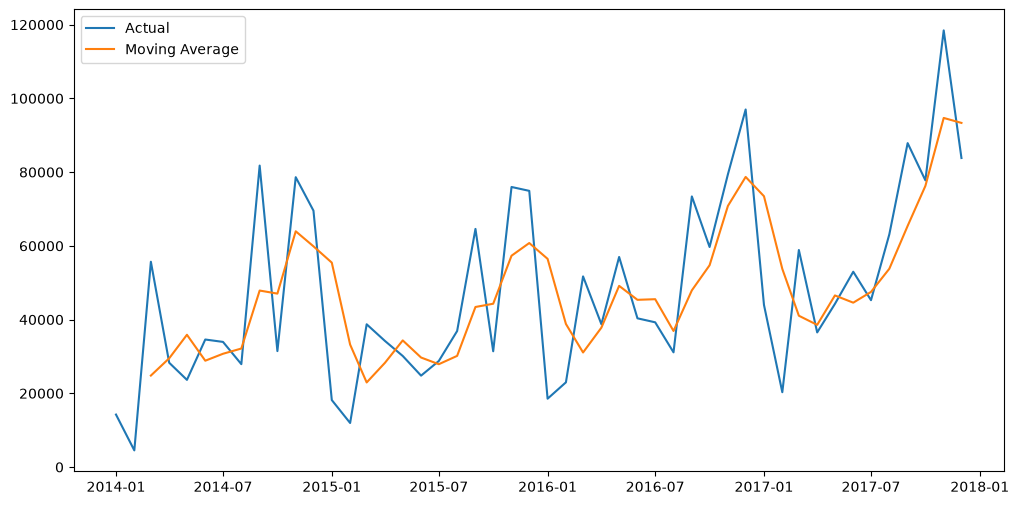

In [12]:
#Moving Average Forecast
rolling = monthly_sales.rolling(
    window=3
).mean()

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales,
    label="Actual"
)

plt.plot(
    rolling,
    label="Moving Average"
)

plt.legend()

plt.savefig(
    "images/moving_average.png"
)

plt.show()

In [13]:
#Customer Segmentation(K-Means)
#Prepare Features
customer = df.groupby(
    "Customer Name"
).agg({

    "Sales":"sum",
    "Profit":"sum",
    "Quantity":"sum"

}).reset_index()

In [14]:
#Standard Scaler
X = customer[
    ["Sales","Profit","Quantity"]
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

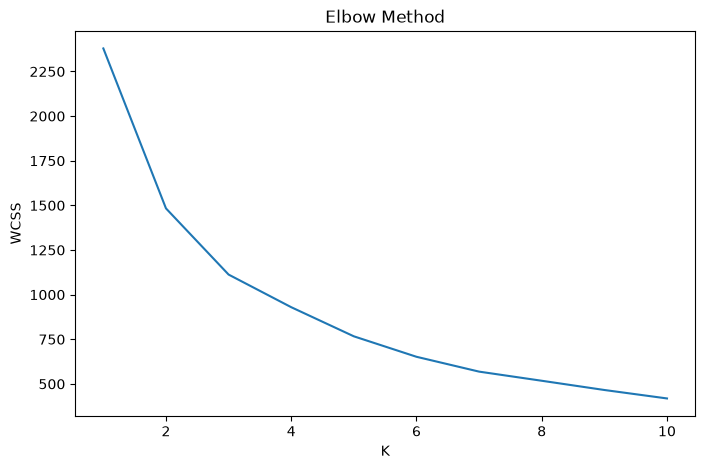

In [15]:
#Elbow Method
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss
)

plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.savefig(
    "images/elbow_method.png"
)

plt.show()

In [16]:
#Apply k=4
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

customer["Cluster"] = kmeans.fit_predict(
    X_scaled
)

In [17]:
#PCA Visualization
pca = PCA(
    n_components=2
)

pca_result = pca.fit_transform(
    X_scaled
)

customer["PCA1"] = pca_result[:,0]
customer["PCA2"] = pca_result[:,1]

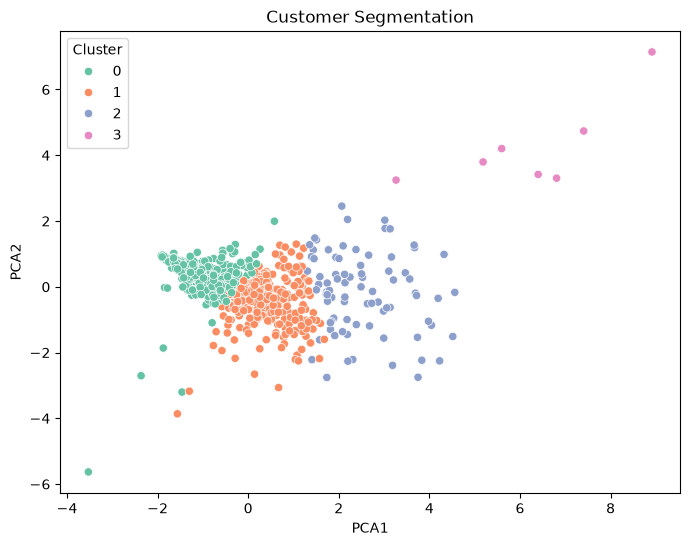

In [18]:
#Plot Clusters
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=customer,

    x="PCA1",
    y="PCA2",

    hue="Cluster",

    palette="Set2"

)

plt.title(
    "Customer Segmentation"
)

plt.savefig(
    "images/customer_clusters.png"
)

plt.show()

In [19]:
#Train-Test Split
X = df[
    ["Quantity","Discount","Profit"]
]

y = df["Sales"]

X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

In [20]:
#Linear Regression
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 41.55,249.57, 1.56]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Quantity','Discount','Profit']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-18.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [21]:
#Prediction
y_pred = model.predict(
    X_test
)

In [22]:
#Evaluation
print(

    "MAE:",

    mean_absolute_error(
        y_test,
        y_pred
    )

)

print(

    "RMSE:",

    np.sqrt(

        mean_squared_error(
            y_test,
            y_pred
        )

    )

)

print(

    "R2 Score:",

    r2_score(
        y_test,
        y_pred
    )

)

MAE: 245.0755698445027
RMSE: 824.8499599151105
R2 Score: -0.15181720106063934


In [23]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":
    model.coef_

})

importance.sort_values(

    by="Coefficient",

    ascending=False

)

,Feature,Coefficient
1,Discount,249.571780
0,Quantity,41.550264
2,Profit,1.561674
